## Part 1

Import the libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

Load the CSV dataset using Pandas

In [2]:
##read_csv("data.csv")
df = pd.read_excel("C:/Users/My/Desktop/Data_Analytics/Python/Project/sales_data_2000_rows (2).xlsx")

Display first 5 rows

In [ ]:
df.head()     

,Order_ID,Date,Product,Category,City,Quantity,Price
0,1001,2025-02-19,Printer,Electronics,Kolkata,3.0,9591
1,1002,2025-08-08,Pen,Stationery,Hyderabad,5.0,318
2,1003,2025-07-28,Mouse,Electronics,Chennai,1.0,697
3,1004,2025-08-15,Chair,Furniture,Ahmedabad,1.0,3410
4,1005,2025-04-12,Mouse,Electronics,Mumbai,NaN,624


Check Dataset Information

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Order_ID  2000 non-null   int64  
 1   Date      2000 non-null   str    
 2   Product   2000 non-null   str    
 3   Category  2000 non-null   str    
 4   City      2000 non-null   str    
 5   Quantity  1999 non-null   float64
 6   Price     2000 non-null   int64  
dtypes: float64(1), int64(2), str(4)
memory usage: 109.5 KB


##Expected Libraries
*pandas
*matplotlib

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

Part 2 — Data Cleaning
Tasks

In [6]:
##Check missing values

print("Missing values:")
print(df.isnull().sum())

Missing values:
Order_ID    0
Date        0
Product     0
Category    0
City        0
Quantity    1
Price       0
dtype: int64


In [7]:
##Remove duplicate records

## Check duplicate records
print("Duplicate records:", df.duplicated().sum())

## Remove duplicates
df = df.drop_duplicates()

Duplicate records: 0


In [8]:
##Correct spelling mistakes if any

df['Product'] = df['Product'].replace({
    'Pen': 'Pens'
})

In [9]:
##Convert Date column into datetime format
df['Date'] = pd.to_datetime(df['Date'])
df.dtypes

Order_ID             int64
Date        datetime64[us]
Product                str
Category               str
City                   str
Quantity           float64
Price                int64
dtype: object

In [10]:
##Expected Output - Clean and structured dataset.

df.head()

,Order_ID,Date,Product,Category,City,Quantity,Price
0,1001,2025-02-19,Printer,Electronics,Kolkata,3.0,9591
1,1002,2025-08-08,Pens,Stationery,Hyderabad,5.0,318
2,1003,2025-07-28,Mouse,Electronics,Chennai,1.0,697
3,1004,2025-08-15,Chair,Furniture,Ahmedabad,1.0,3410
4,1005,2025-04-12,Mouse,Electronics,Mumbai,NaN,624


Part 3 — Data Processing
Tasks

In [11]:
##Create a new column:
##Revenue = Quantity × Price

df['Revenue'] = df['Quantity'] * df['Price']

In [12]:
##Add the Revenue column to the dataset. 
df.head()

,Order_ID,Date,Product,Category,City,Quantity,Price,Revenue
0,1001,2025-02-19,Printer,Electronics,Kolkata,3.0,9591,28773.0
1,1002,2025-08-08,Pens,Stationery,Hyderabad,5.0,318,1590.0
2,1003,2025-07-28,Mouse,Electronics,Chennai,1.0,697,697.0
3,1004,2025-08-15,Chair,Furniture,Ahmedabad,1.0,3410,3410.0
4,1005,2025-04-12,Mouse,Electronics,Mumbai,NaN,624,NaN


Part 4 — Data Analysis 

In [13]:
##Task 1 — Total Revenue
##Find:  Total sales revenue of the company

total_revenue = df["Revenue"].sum()

print("Total Revenue:", total_revenue)

Total Revenue: 51500062.0


In [14]:
##Task 2 — Best Selling Product
##Find: Product with highest quantity sold

product_sales = df.groupby("Product")["Quantity"].sum()

best_selling_product = product_sales.idxmax()
highest_quantity = product_sales.max()

print("Best Selling Product:", best_selling_product)
print("Highest Quantity Sold:", highest_quantity)

Best Selling Product: Chair
Highest Quantity Sold: 568.0


In [15]:
df.columns

Index(['Order_ID', 'Date', 'Product', 'Category', 'City', 'Quantity', 'Price',
       'Revenue'],
      dtype='str')

In [16]:
df["Revenue"] = df["Quantity"] * df["Price"]

In [17]:
##Task 3 — Best Performing City
##Find:City with highest revenue

city_revenue = df.groupby("City")["Revenue"].sum()

best_city  = city_revenue.idxmax()
highest_revenue  = city_revenue.max()

print("Best Performing City:", best_city)
print("Highest City Revenue:", highest_revenue)

Best Performing City: Ahmedabad
Highest City Revenue: 7449911.0


In [18]:
##Task 4 — Category Analysis
##Find:Revenue generated by each category

category_revenue = df.groupby("Category")["Revenue"].sum()

print(category_revenue)

Category
Accessories      905769.0
Electronics    37093350.0
Furniture      13343784.0
Stationery       157159.0
Name: Revenue, dtype: float64


In [19]:
##Task 5 — Monthly Sales Analysis
##Find:Total revenue generated per month

df["Date"] = pd.to_datetime(df["Date"])

In [20]:
df["Month"] = df["Date"].dt.to_period("M")

In [21]:
monthly_revenue = df.groupby("Month")["Revenue"].sum()

print(monthly_revenue)

Month
2025-01    4021909.0
2025-02    3655339.0
2025-03    4607846.0
2025-04    4783602.0
2025-05    4884091.0
2025-06    3654206.0
2025-07    3979183.0
2025-08    4012286.0
2025-09    4318017.0
2025-10    4428577.0
2025-11    4185989.0
2025-12    4891185.0
2026-01      77832.0
Freq: M, Name: Revenue, dtype: float64


Part 5 — Data Visualization

Create the following charts:

Bar Chart -Revenue by City
Pie Chart- Category contribution
Line Chart-  Monthly sales trend

<Axes: title={'center': 'Revenue by City'}, xlabel='City', ylabel='Revenue'>

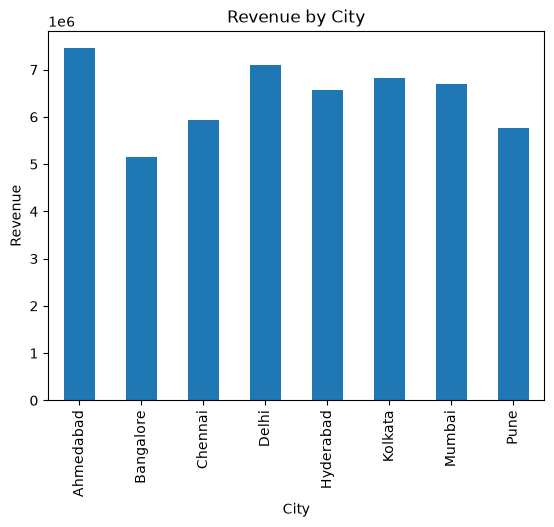

In [22]:
##Bar Chart -Revenue by City

city_revenue = df.groupby("City")["Revenue"].sum()

city_revenue.plot(
    kind="bar",
    title="Revenue by City",
    xlabel="City",
    ylabel="Revenue"
)

<Axes: title={'center': 'Category Contribution'}>

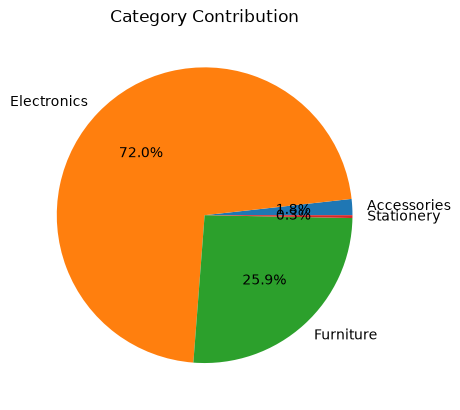

In [23]:
##Pie Chart- Category contribution

category_revenue = df.groupby("Category")["Revenue"].sum()

category_revenue.plot(
    kind="pie",
    autopct="%1.1f%%",
    title="Category Contribution",
    ylabel=""
)

<Axes: title={'center': 'Monthly Sales Trend'}, xlabel='Month', ylabel='Revenue'>

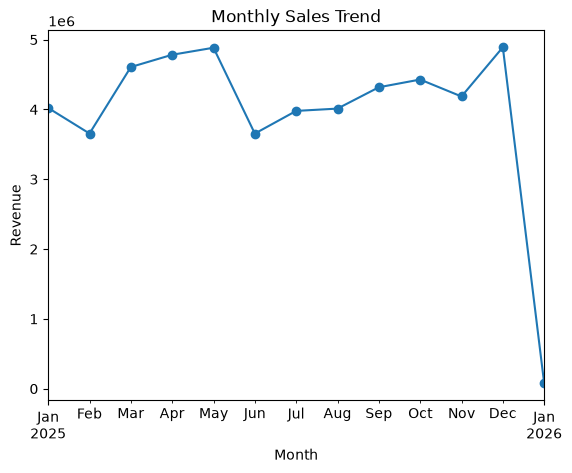

In [24]:
##Line Chart-  Monthly sales trend

monthly_revenue.plot(
    kind="line",
    marker="o",
    title="Monthly Sales Trend",
    xlabel="Month",
    ylabel="Revenue"
)

Part 6 — Business Insights

Students must write minimum 5 insights from the analysis.

Example
Electronics products sell frequently
Furniture generates higher revenue
Chennai has highest customer spending





Part 7 — Recommendations

Students must provide minimum 3 business recommendations.

Example
Increase advertisements for high-selling products
Improve marketing in low-performing cities
Offer discounts during low-sales months


1. Focus more on promoting products with high sales volume.
2. Strengthen marketing activities in cities with lower revenue.
3. Introduce seasonal offers and discounts during low-revenue months.